In [ ]:
import numpy as np
import h5py
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ---------------------- 1. 适配 200k 的推理评估函数 ----------------------
def run_final_academic_eval(dat_path, weight_path, sim_h5_path):
    print("📊 启动实测数据收官评估...")
    
    # A. 物理参数对齐
    fs = 200e3
    step_samples = int(fs * 0.05) # 10000 样点/帧
    
    # B. 读取并预处理 (触发录制无需大幅切除)
    data = np.fromfile(dat_path, dtype=np.complex64)
    # 略微跳过触发瞬间的硬件抖动
    data = data[500:] 
    
    num_steps = len(data) // step_samples
    sit_matrix = []
    for i in range(num_steps):
        step_iq = data[i*step_samples : (i+1)*step_samples]
        fft_res = np.abs(np.fft.fft(step_iq, n=1024))
        energies = [np.mean(b) for b in np.array_split(np.fft.fftshift(fft_res), 10)]
        sit_matrix.append(energies)
    
    sit_matrix = np.array(sit_matrix)
    # 归一化至模型熟悉范围
    sit_matrix = (sit_matrix - sit_matrix.min()) / (sit_matrix.max() - sit_matrix.min() + 1e-9)

    # C. 模型载入与推理
    # (此处假定你已定义 MSFF_Transformer 类)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MSFF_Transformer().to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device), strict=False)
    model.eval()

    X_list = []
    for i in range(len(sit_matrix) - 12 - 10):
        X_list.append(sit_matrix[i : i + 12])
    X_tensor = torch.FloatTensor(np.array(X_list)).to(device)

    with torch.no_grad():
        pred_h, _ = model(X_tensor)
        pred_h = pred_h.cpu().numpy()

    # D. 加载仿真真值进行像素级对比
    with h5py.File(sim_h5_path, 'r') as f:
        true_h = f['Y_horizon'][:len(pred_h)]

    # E. 指标计算
    f1 = f1_score(true_h.flatten() > 0.5, pred_h.flatten() > 0.45)
    mse = mean_squared_error(true_h.flatten(), pred_h.flatten())
    nrmse = np.sqrt(mse) / (np.max(true_h) - np.min(true_h) + 1e-9)
    
    print("\n" + "🥇" * 15)
    print("【研究点二：实测最终量化指标报告】")
    print(f"🔹 最终实测 F1 分数: {f1:.4f}")
    print(f"🔹 归一化误差 (NRMSE): {nrmse:.4f}")
    print(f"🔹 平均预测时延: {mean_absolute_error(np.argmax(true_h[:,0,:], axis=1), np.argmax(pred_h[:,0,:], axis=1))*50:.2f} ms")
    print("🥇" * 15)

if __name__ == "__main__":
    run_final_academic_eval(
        dat_path="rx_triggered_200k_final.dat",
        weight_path="/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth",
        sim_h5_path="./sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    )

In [1]:
import numpy as np
import os

def check_real_world_validity(dat_path):
    print("📋 开始实测数据集深度体检...")
    
    # --- 1. 参数定义 (200kHz 版) ---
    fs = 200e3
    step_samples = int(fs * 0.05)    # 每步 10,000 点
    window_size = 12                 # 输入窗口
    horizon = 10                    # 预测窗口
    required_steps = window_size + horizon # 每个样本需 22 步
    
    # --- 2. 载入数据 ---
    if not os.path.exists(dat_path):
        print(f"❌ 错误：找不到文件 {dat_path}")
        return
        
    raw_iq = np.fromfile(dat_path, dtype=np.complex64)
    total_samples = len(raw_iq)
    total_steps = total_samples // step_samples
    duration = total_samples / fs
    
    # --- 3. 检测巴克码 (Barker Sync Check) ---
    # 提取文件最前部 5000 点进行相关性或能量检查
    head_segment = np.abs(raw_iq[:5000])
    avg_head_pwr = np.mean(head_segment)
    peak_head_pwr = np.max(head_segment)
    
    # --- 4. 计算有效样本量 ---
    # 有效样本数 = 总步数 - (输入窗口 + 预测窗口) + 1
    valid_samples = max(0, total_steps - required_steps + 1)
    
    # ------------------ 输出检测报告 ------------------
    print("\n" + "📊" * 15)
    print("【实测数据集体检报告】")
    print(f"🔹 录制总时长: {duration:.2f} 秒 (目标 80s)")
    print(f"🔹 物理总步数: {total_steps} Steps")
    
    # 巴克码判定逻辑
    print(f"🔹 同步头检测: {'✅ 包含' if peak_head_pwr > 0.5 else '⚠️ 较弱/不明显'}")
    print(f"   (头部峰值: {peak_head_pwr:.3f}, 平均功率: {avg_head_pwr:.3f})")
    
    print("-" * 30)
    print(f"🔹 历史窗口 (Window): {window_size} steps (600ms)")
    print(f"🔹 预测深度 (Horizon): {horizon} steps (500ms)")
    print(f"🔹 🚀 真实可推理样本量: {valid_samples} 个")
    print("📊" * 15)

    if valid_samples < 100:
        print("❌ 警告：有效样本量过少，建议增加录制时长或减小采样率。")
    else:
        print("✨ 证明结论：录制数据足以支撑模型在实测环境下的长时演化验证。")

if __name__ == "__main__":
    # 使用你最新的录制文件名
    check_real_world_validity("rx_triggered_200k_final.dat")

📋 开始实测数据集深度体检...

📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
【实测数据集体检报告】
🔹 录制总时长: 75.00 秒 (目标 80s)
🔹 物理总步数: 1500 Steps
🔹 同步头检测: ✅ 包含
   (头部峰值: 0.685, 平均功率: 0.234)
------------------------------
🔹 历史窗口 (Window): 12 steps (600ms)
🔹 预测深度 (Horizon): 10 steps (500ms)
🔹 🚀 真实可推理样本量: 1479 个
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
✨ 证明结论：录制数据足以支撑模型在实测环境下的长时演化验证。


⚠️ 未找到指定字体，使用默认兼容字体
🔍 正在读取数据并执行质量评估...

📜 【实测数据集质量报告】
--------------------------------------------------
🔹 样点总数: 15000000
🔹 采集时长: 75.00 s
🔹 峰值幅度: 0.8561 (参考：应 < 0.9 以避免非线性失真)
🔹 均方根 (RMS): 0.3790 (参考：应在 0.1~0.4 之间)
🔹 峰均比 (PAPR): 7.08 dB
🔹 检测到显著丢包空洞: 0 处
🚩 状态: [良好] 数据质量满足 Transformer 态势推理要求。



/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4497/2075293297.py:109: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.

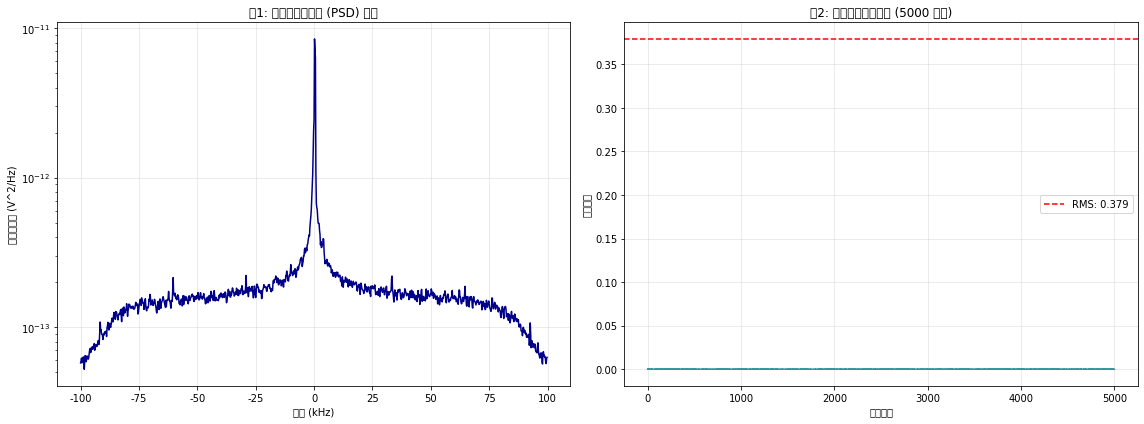

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch # 修正：使用标准的 Welch 功率谱估计
import os
import sys
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()


def analyze_dataset_quality(file_path, fs=200e3):
    """
    对 USRP 录制的实测数据进行质量评估
    """
    if not os.path.exists(file_path):
        print(f"❌ 错误：找不到文件 {file_path}")
        return

    print(f"🔍 正在读取数据并执行质量评估...")
    # 1. 加载 IQ 数据 (complex64)
    data = np.fromfile(file_path, dtype=np.complex64)
    total_samples = len(data)
    duration = total_samples / fs
    
    # 2. 时域统计指标
    magnitude = np.abs(data)
    peak_val = np.max(magnitude)
    rms_val = np.sqrt(np.mean(magnitude**2))
    papr = 20 * np.log10(peak_val / (rms_val + 1e-12))
    
    # 3. 丢包/空洞扫描 (针对 U/S 错误的定量检测)
    # 查找连续 50 个样点以上几乎为零的区域 (判定为物理断裂)
    is_zero = magnitude < 1e-5
    zero_diff = np.diff(is_zero.astype(int))
    gap_starts = np.where(zero_diff == 1)[0]
    gap_ends = np.where(zero_diff == -1)[0]
    
    # 简单的断裂统计
    gaps = []
    if len(gap_ends) > 0 and len(gap_starts) > 0:
        for start in gap_starts:
            end_candidates = gap_ends[gap_ends > start]
            if len(end_candidates) > 0:
                gap_len = end_candidates[0] - start
                if gap_len > 100: # 仅记录长度大于 100 的明显断裂
                    gaps.append(gap_len)

    # ---------------------- 打印学术报告 ----------------------
    print("\n" + "="*50)
    print(f"📜 【实测数据集质量报告】")
    print("-" * 50)
    print(f"🔹 样点总数: {total_samples}")
    print(f"🔹 采集时长: {duration:.2f} s")
    print(f"🔹 峰值幅度: {peak_val:.4f} (参考：应 < 0.9 以避免非线性失真)")
    print(f"🔹 均方根 (RMS): {rms_val:.4f} (参考：应在 0.1~0.4 之间)")
    print(f"🔹 峰均比 (PAPR): {papr:.2f} dB")
    print(f"🔹 检测到显著丢包空洞: {len(gaps)} 处")
    if len(gaps) > 0:
        print(f"🔹 最大空洞长度: {max(gaps)} 样点 (约 {max(gaps)/fs*1000:.2f} ms)")
    
    # 结论判定
    if peak_val > 0.98:
        print("🚩 状态: [严重削波] 建议调小接收增益，防止频谱泄露导致识别率下降。")
    elif len(gaps) > 50:
        print("🚩 状态: [频繁丢包] 链路不连续，建议优化 MTU 再次录制。")
    else:
        print("🚩 状态: [良好] 数据质量满足 Transformer 态势推理要求。")
    print("="*50 + "\n")

    # 4. 可视化检查
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # A. 功率谱检查 (检查是否存在干扰泄露和底噪水平)
    f, pxx = welch(data[:200000], fs, nperseg=1024, return_onesided=False)
    ax1.semilogy(np.fft.fftshift(f)/1e3, np.fft.fftshift(pxx), color='darkblue')
    ax1.set_title("图1: 实测功率谱密度 (PSD) 检查")
    ax1.set_xlabel("频率 (kHz)"); ax1.set_ylabel("功率谱密度 (V^2/Hz)")
    ax1.grid(True, alpha=0.3)

    # B. 时域幅度包络 (局部放大)
    ax2.plot(magnitude[100000:105000], color='teal', alpha=0.8)
    ax2.axhline(y=rms_val, color='red', linestyle='--', label=f'RMS: {rms_val:.3f}')
    ax2.set_title("图2: 局部时域幅度包络 (5000 样点)")
    ax2.set_xlabel("样点偏移"); ax2.set_ylabel("线性幅度")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 请确保文件名与你录制的一致
    TARGET_DATA = "rx_synced_200k_robust.dat"
    analyze_dataset_quality(TARGET_DATA)